In [1]:
import sys
sys.path.insert(0, '../lib')

In [2]:
import joblib
import os
import pathlib

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.multitest

import common_data
import pb_utils

In [3]:
pd.options.display.max_columns = 200
pd.options.display.max_rows = 200
%config InlineBackend.figure_format = "retina"

In [ ]:
ROOT = common_data.DATA

In [ ]:
BASE = ROOT / '05_pseudobulk/50c_degs'

In [ ]:
PADJ_CUTOFF = 0.05
class ComparisonInfo:
    def __init__(self, control, condition, genes, genes_to_keep):
        self.control = control
        self.condition = condition
        self.genes_raw = genes
        self.filter_genes(genes_to_keep)

    def filter_genes(self, genes_to_keep):
        filtered_degs = self.genes_raw.loc[self.genes_raw.index.isin(genes_to_keep), :].copy()
        filtered_degs = filtered_degs.loc[filtered_degs.pvalue.notna()].copy()
        filtered_degs['padj'] = statsmodels.stats.multitest.fdrcorrection(
            filtered_degs.pvalue,
            alpha=PADJ_CUTOFF
        )[1]
        # recompute gene status based on new `padj`
        filtered_degs['sign'] = ''
        filtered_degs.loc[
            filtered_degs.padj.lt(PADJ_CUTOFF)
            & filtered_degs.log2FoldChange.gt(0),
            'sign'
        ] = f'Up in {self.condition}'
        filtered_degs.loc[
            filtered_degs.padj.lt(PADJ_CUTOFF)
            & filtered_degs.log2FoldChange.lt(0),
            'sign'
        ] = f'Up in {self.control}'
        self.genes = filtered_degs


class CellTypeInfo:
    def __init__(self, path, task_info, genes_to_keep):
        self.path = path
        self.task_info = task_info
        self.comparisons = []
        self.meta = pd.read_csv(path / 'meta.csv', index_col=0)
        self.name = self.meta.cell_type.values[0]

        self.load_comparisons(genes_to_keep)

    def load_comparisons(self, genes_to_keep):
        for run in self.path.glob('**/degs.csv'):
            self.comparisons.append(
                ComparisonInfo(
                    self.task_info.column_values[0],
                    self.task_info.column_values[1],
                    pd.read_csv(run, index_col=0),
                    genes_to_keep[self.name]
                )
            )

    @property
    def n_comparisons(self):
        return len(self.comparisons)

In [7]:
class TaskData:
    def __init__(self, task, task_info):
        self.task = task
        self.task_info = task_info
        self.info = {}

In [ ]:
data = joblib.load('50c_deg_data.joblib')

In [9]:
data

{'gram+_vs_gram-': <__main__.TaskData at 0x14f283740be0>,
 'pseudomonas_vs_gram-': <__main__.TaskData at 0x14f283752530>,
 'age': <__main__.TaskData at 0x14f280938790>,
 'sex': <__main__.TaskData at 0x14f27e1ca500>,
 'immunocompromised': <__main__.TaskData at 0x14f27bbe7a30>,
 'days_on_vent': <__main__.TaskData at 0x14f27895c640>,
 'steroid_dose': <__main__.TaskData at 0x14f27643c0d0>}

In [10]:
task_pairs = {
    'gram+_vs_gram-': ('Gram+', 'Gram–'),
    'pseudomonas_vs_gram-': ('Pseudomonas', 'Other Gram–'),
    'age': ('Age < 65', 'Age >= 65'),
    'sex': ('Male', 'Female'),
    'immunocompromised': ('Not immunocompromised', 'Immunocompromised'),
    'days_on_vent': ('< 2 vent days', '> 16 vent days'),
    'steroid_dose': ('<= 600 steroid dose', '> 600 steroid dose')
}

In [11]:
n_degs_plot = pd.DataFrame()
n_degs = pd.DataFrame()
for task_data in data.values():
    for ct, info in task_data.info.items():
        # name = ' vs '.join(task_data.task_info.column_values)
        name = task_data.task_info.pathname
        n_genes = info.comparisons[0].genes.padj.lt(PADJ_CUTOFF).sum()
        n_degs.loc[ct, name] = n_genes
        if n_genes > 0:
            n_genes = np.log10(n_genes)
        n_degs_plot.loc[ct, name] = n_genes
n_degs = n_degs.sort_index().T.sort_index()
n_degs_plot = n_degs_plot.sort_index().T.sort_index()

Text(0.5, 1.0, 'Number of DEGs')

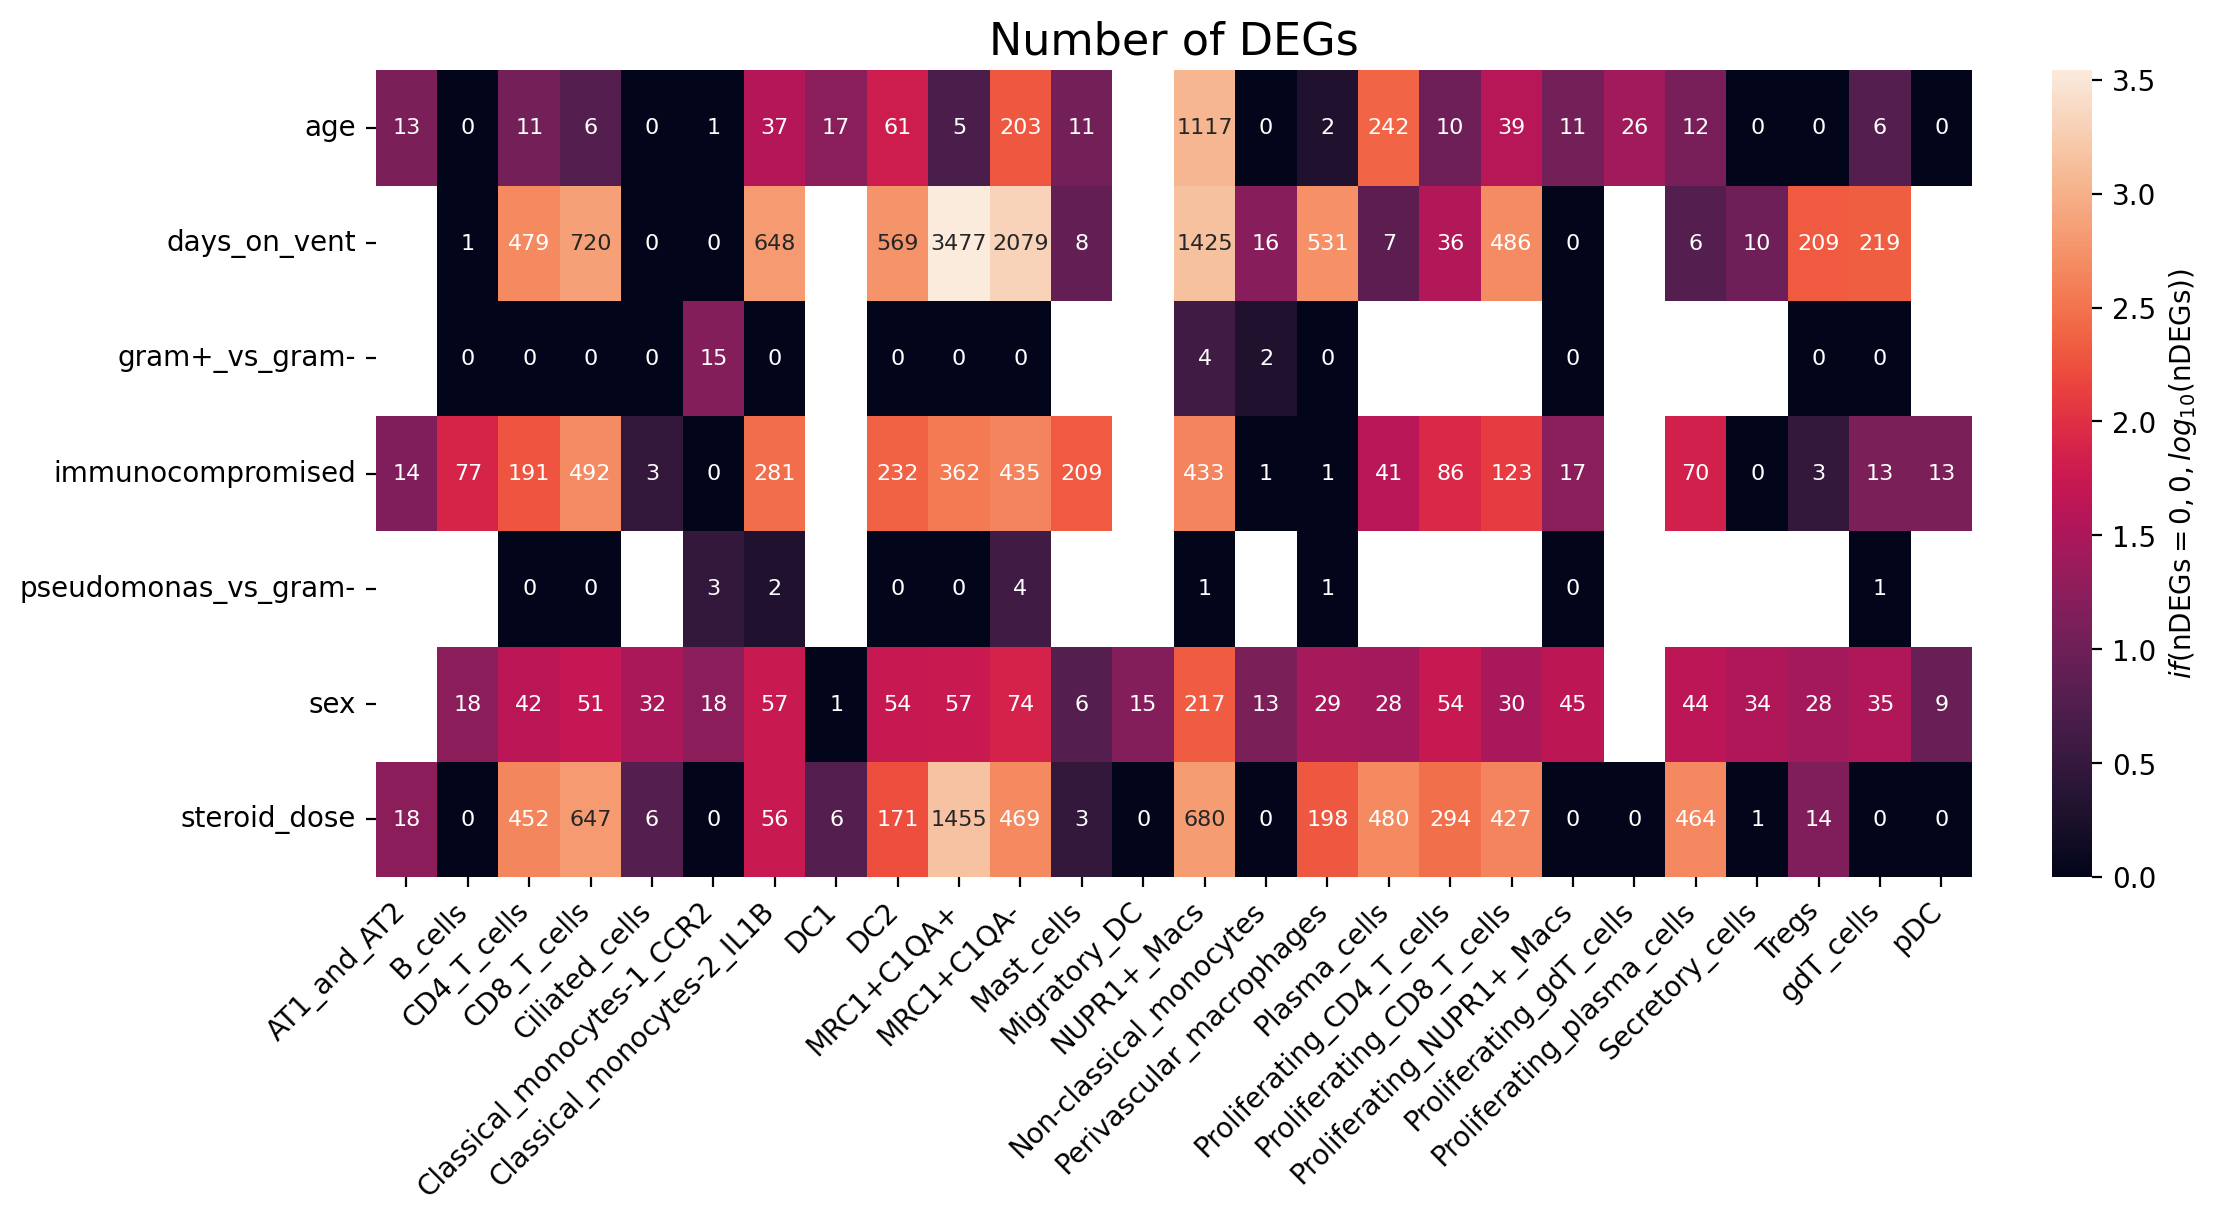

In [12]:
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
sns.heatmap(
    n_degs_plot,
    cbar_kws=dict(
        label='$if(\mathrm{nDEGs} = 0, 0, log_{10}(\mathrm{n DEGs}))$'
    ),
    annot=n_degs,
    fmt='.0f',
    annot_kws=dict(
        size=8
    ),
    ax=ax
)
trans = mpl.transforms.Affine2D().translate(6, 0)
for t in ax.get_xticklabels():
    t.set_ha('right')
    t.set_rotation(45)
    t.set_transform(t.get_transform() + trans)
ax.set_title('Number of DEGs', size=16)

In [ ]:
n_degs.to_csv('70_degs/50c_deg_counts.csv')

In [14]:
result = {}
for _, task in data.items():
    gseas = []
    for k, ct_info in task.info.items():
        comp = ct_info.comparisons[0]
        gsea_path = BASE / task.task_info.pathname / k / 'gsea.csv'
        if not gsea_path.exists():
            print(f'No GSEA for {k} in {task.task_info.pathname}')
            continue
        gsea = pd.read_csv(gsea_path, index_col=0)
        gsea['cell_type'] = k
        gseas.append(gsea)
    result[task.task_info.pathname] = pd.concat(gseas)

No GSEA for pDC in immunocompromised


### Save data for interactive exploration

In [ ]:
for d in data.values():
    gsea_path = f'70_degs/{d.task_info.pathname}_gsea.csv'
    gsea = result[d.task_info.pathname]
    gsea['p-value'] = gsea['NOM p-value'].copy()
    idx = gsea['p-value'].eq(0)
    min_p_val = gsea['p-value'][~idx].min()
    gsea.loc[idx, 'p-value'] = min_p_val * 0.01
    gsea['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea['p-value'])[1]
    gsea['-log10(padj)'] = -np.log10(gsea.padj)
    gsea['-log10(padj)'] *= np.sign(gsea.NES)
    result[d.task_info.pathname].to_csv(gsea_path)

In [16]:
secretome = pd.read_table('protein_class_Predicted.tsv')

In [ ]:
for d in data.values():
    for ct in d.info.keys():
        deg_path = f'70_degs/{d.task_info.pathname}/{ct}_degs.csv'
        degs = d.info[ct].comparisons[0].genes
        degs['secretome'] = pd.Series(degs.index.isin(secretome.Gene)).replace(
            {True: 'Yes', False: ''}
        ).values
        os.makedirs(os.path.dirname(deg_path), exist_ok=True)
        degs.to_csv(deg_path)

In [ ]:
result = []
for d in data.values():
    task_info = d.task_info
    group1 = task_info.column_values[0]
    group2 = task_info.column_values[1]
    for ct in d.info.keys():
        meta = d.info[ct].meta
        group1_count = meta.group.astype(str).eq('0').sum()
        group2_count = meta.group.astype(str).eq('1').sum()
        discard_count = meta.group.eq('discard').sum()
        group1_up = d.info[ct].comparisons[0].genes.sign.eq(f'Up in {group1}').sum()
        group2_up = d.info[ct].comparisons[0].genes.sign.eq(f'Up in {group2}').sum()
        result.append(
            {
                'cell_type': ct,
                'task': task_info.pathname,
                'group1': group1,
                'group2': group2,
                'group1_count': group1_count,
                'group2_count': group2_count,
                'discard_count': discard_count,
                'group1_up': group1_up,
                'group2_up': group2_up
            }
        )
result = pd.DataFrame(result)
result.to_csv('70_degs/50c_deg_stats.csv')